### System of study

HBQ (2-(2′-hydroxyphenyl)benzoxazole) is an organic heterocyclic molecule widely studied for its unique photophysical properties. It is best known for exhibiting excited-state intramolecular proton transfer (ESIPT), a process that occurs after light absorption and leads to strong fluorescence with a large Stokes shift. Because of this behavior, HBQ serves as an important model compound in photochemistry and is used in the development of fluorescent sensors, bioimaging probes, and optoelectronic materials such as OLEDs.

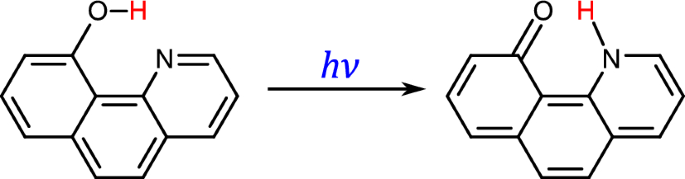

### Transition dipole moment

In HBQ, which undergoes excited-state intramolecular proton transfer (ESIPT), the transition dipole moment (TDM) is crucial because it determines how strongly the molecule interacts with light. The TDM controls the intensity of absorption and emission, meaning it directly affects fluorescence efficiency. During proton transfer, the molecular geometry and electronic distribution change significantly between the enol and keto forms, leading to variations in the transition dipole moment. By predicting the TDM from molecular geometries, we can understand how structural changes along the proton transfer coordinate influence the optical properties of HBQ. This is essential for accurately modeling its photodynamics and fluorescence behavior.

### Molecular dynamics simulations

TODO: MD results description

### What we know about our data?

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

### 1. Dipole moment distribution

In [3]:
data = pd.read_csv("trajs-dataframe-pc.csv")
data

,TRAJ,Time,x1,y1,z1,x2,y2,z2,x3,y3,...,z23,x24,y24,z24,mu_x,mu_y,mu_z,mu_x_pc,mu_y_pc,mu_z_pc
0,1,0.5,-0.903948,2.567011,0.066012,1.375391,1.360069,-0.122150,0.848979,0.165433,...,0.206331,-4.208275,-0.299556,-0.045503,-1.298255,0.060673,-0.002043,-1.298255,0.060673,-0.002043
1,1,1.0,-0.903835,2.562395,0.065014,1.380791,1.361061,-0.124760,0.841877,0.155487,...,0.193118,-4.222286,-0.319823,-0.051924,1.330744,-0.063285,0.004413,-1.330744,0.063285,-0.004413
2,1,1.5,-0.903613,2.557535,0.064056,1.385793,1.362369,-0.127433,0.834433,0.145367,...,0.180662,-4.265446,-0.344548,-0.060105,-1.377839,0.065160,-0.006069,-1.377839,0.065160,-0.006069
3,1,2.0,-0.903245,2.552448,0.063149,1.390274,1.363923,-0.130158,0.826782,0.135235,...,0.169053,-4.328030,-0.371130,-0.069135,1.431230,-0.067969,0.006861,-1.431230,0.067969,-0.006861
4,1,2.5,-0.902709,2.547157,0.062301,1.394119,1.365663,-0.132925,0.819068,0.125243,...,0.158393,-4.399876,-0.396572,-0.077975,1.484248,-0.072878,0.006718,-1.484248,0.072878,-0.006718
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42995,215,98.0,-0.934367,2.541373,0.038740,1.475924,1.438822,0.065239,0.778559,0.125982,...,0.018664,-4.513288,-0.037115,-0.031534,-1.884159,0.072271,-0.012103,-1.884159,0.072271,-0.012103
42996,215,98.5,-0.930888,2.543931,0.038357,1.476764,1.435126,0.065179,0.778242,0.132994,...,0.006837,-4.498413,-0.056363,-0.037674,1.861778,-0.057815,0.010398,-1.861778,0.057815,-0.010398
42997,215,99.0,-0.927550,2.546153,0.037961,1.477164,1.430590,0.064979,0.778772,0.140455,...,-0.004734,-4.487472,-0.077722,-0.043962,-1.829654,0.037963,-0.008759,-1.829654,0.037963,-0.008759
42998,215,99.5,-0.924355,2.548018,0.037551,1.477064,1.425246,0.064641,0.780161,0.148247,...,-0.015892,-4.482751,-0.100842,-0.050284,1.787543,-0.012123,0.007323,-1.787543,0.012123,-0.007323


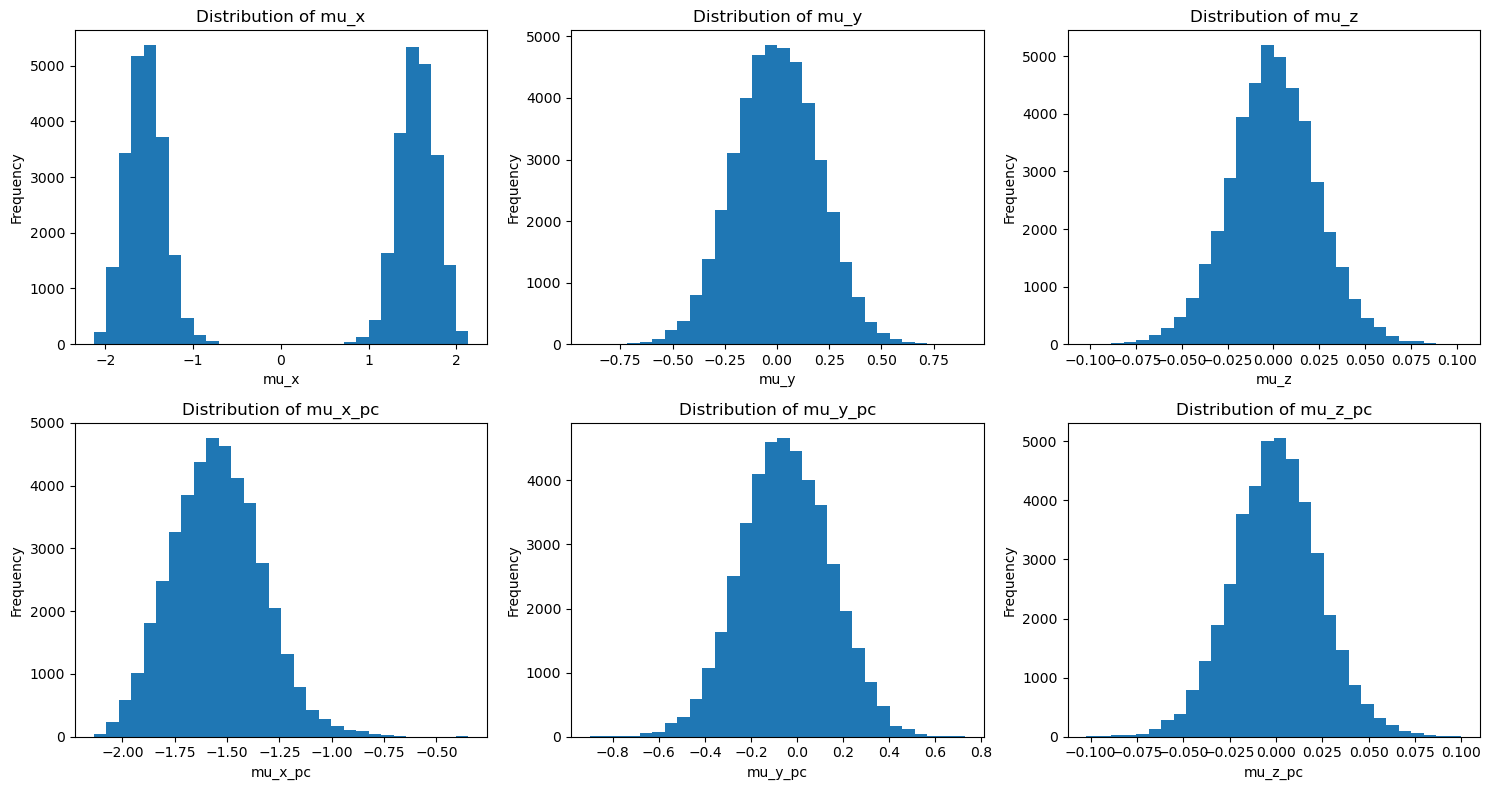

In [11]:
columns = ["mu_x", "mu_y", "mu_z", "mu_x_pc", "mu_y_pc", "mu_z_pc"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))  # 2 rows, 3 columns
axes = axes.flatten()  # Flatten 2D array of axes into 1D for easy looping

for ax, col in zip(axes, columns):
    ax.hist(data[col].dropna(), bins=30)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### 2. Geometries variation 

In [12]:
from sklearn.feature_selection import VarianceThreshold

In [19]:
# concatenated ccordinates
coords = data.drop(columns=["TRAJ", "Time", "mu_x", "mu_y", "mu_z", "mu_x_pc", "mu_y_pc", "mu_z_pc"])
# coords = coords.values

In [20]:
deviation = 0.1 # angstrem
threshold = deviation ** 2

In [21]:
selector = VarianceThreshold(threshold=threshold)
x_reduced = selector.fit_transform(coords)

low_var_mask = ~selector.get_support()

In [22]:
low_var_mask

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
       False, False, False, False,  True, False, False, False, False,
       False, False, False, False,  True, False, False,  True, False,
       False, False, False,  True, False, False,  True, False, False])

In [23]:
coords.columns[low_var_mask]

Index(['x1', 'y1', 'z1', 'x2', 'y2', 'z2', 'x3', 'y3', 'z3', 'x4', 'y4', 'z4',
       'x5', 'y5', 'z5', 'x6', 'y6', 'z6', 'x7', 'y7', 'z7', 'x8', 'y8', 'z8',
       'x9', 'y9', 'z9', 'x10', 'y10', 'z10', 'x11', 'y11', 'z11', 'x12',
       'y12', 'z12', 'x13', 'y13', 'z13', 'x14', 'y14', 'z14', 'x15', 'y15',
       'z15', 'y17', 'y20', 'y21', 'x23', 'x24'],
      dtype='object')